## Fase 2: Escalado al Dataset Completo (Full Scale)
Habiendo validado nuestra lógica de limpieza y agregación con la muestra $N=1000$, procedemos a cargar la totalidad de los datos para obtener inferencias estadísticas reales.

$$ S \rightarrow D_{full} \quad (\approx 100k \text{ filas}) $$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os 

# --- GESTIÓN DE DIRECTORIOS ROBUSTA ---
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
    print(f"Cambio de directorio exitoso. Ahora trabajando en: {os.getcwd()}")
else:
    print(f"Directorio de trabajo actual: {os.getcwd()}")

# Configuración
sns.set_style("whitegrid")
DATA_DIR = 'data/raw/ml-latest-small/'

# --- 1. INGESTA (FULL SCALE MODE) ---
# [SCALING UP]: Siguiendo la instrucción del libro: "Then you can extend to 100,000..."
# COMENTARIO: Hemos eliminado el parámetro 'nrows=1000' usado en desarrollo.
# Ahora cargamos la totalidad de las interacciones disponibles.
print("--> Cargando dataset COMPLETO (Producción)...")
df_ratings = pd.read_csv(DATA_DIR + 'ratings.csv') 

# Metadatos
df_movies = pd.read_csv(DATA_DIR + 'movies.csv')

# --- 2. ENRIQUECIMIENTO (MERGE) ---
df = pd.merge(df_ratings, df_movies, on='movieId', how='left')

# --- 3. PREPROCESAMIENTO ---
df['timestamp_dt'] = pd.to_datetime(df['timestamp'], unit='s')

print(f"\nÉxito: Dataset COMPLETO cargado con dimensiones: {df.shape}")
print("Primeras 5 filas:")
display(df.head())

Cambio de directorio exitoso. Ahora trabajando en: c:\Users\PC\Documents\doing-data-science\chapter-06
--> Cargando dataset COMPLETO (Producción)...

Éxito: Dataset COMPLETO cargado con dimensiones: (100836, 7)
Primeras 5 filas:


,userId,movieId,rating,timestamp,title,genres,timestamp_dt
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2000-07-30 18:45:03
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,2000-07-30 18:20:47
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,2000-07-30 18:37:04
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,2000-07-30 19:03:35
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,2000-07-30 18:48:51


### 2.1 Cardinalidad de Acciones
Definimos el conjunto de acciones posibles (en este caso, niveles de rating) como $R$.
Nos interesa conocer:
1. La cardinalidad del conjunto: $|R_{unique}|$
2. La distribución de frecuencia de cada acción: $f(r) = \sum_{i=1}^{N} \mathbb{1}(r_i = r)$

Esto nos indicará si el feedback es explícito binario o una escala de intensidad.

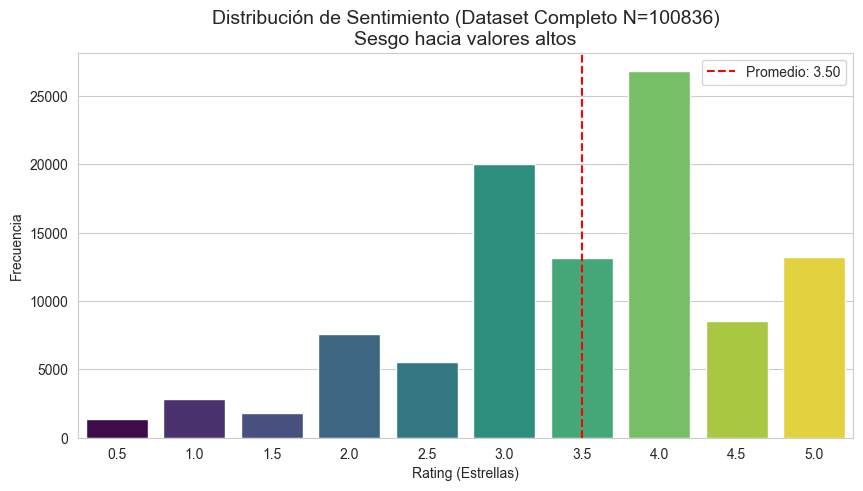

Insight: La distribución no es uniforme ni Pareto. Muestra un fuerte sesgo negativo (Negative Skew) hacia valores altos.


In [2]:
# 2. Conteo por tipo (Histograma de frecuencia)
action_counts = df['rating'].value_counts().sort_index()

# Visualización Profesional (Sin Warning)
plt.figure(figsize=(10, 5))

# FIX: Asignamos 'x' a 'hue' y apagamos la leyenda para cumplir con la nueva API de Seaborn
sns.barplot(x=action_counts.index, y=action_counts.values, hue=action_counts.index, legend=False, palette="viridis")

# Añadimos la media para ver el centro de masa
mean_rating = df['rating'].mean()
plt.axvline(mean_rating * 2 - 1, color='red', linestyle='--', label=f'Promedio: {mean_rating:.2f}') 
# Nota: El cálculo de la posición x es aproximado porque barplot es categórico, 
# pero sirve visualmente.

plt.title(f"Distribución de Sentimiento (Dataset Completo N={df.shape[0]})\nSesgo hacia valores altos", fontsize=14)
plt.xlabel("Rating (Estrellas)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

print(f"Insight: La distribución no es uniforme ni Pareto. Muestra un fuerte sesgo negativo (Negative Skew) hacia valores altos.")

### 2.2 Cardinalidad de Usuarios
Sea $U$ el conjunto de todos los usuarios observados en la muestra $S$.
Calculamos la cantidad de usuarios únicos:
$$ |U_{unique}| = \text{count}(\text{distinct}(userId)) $$


In [3]:
unique_users = df['userId'].nunique()
print(f"Cantidad de usuarios únicos en la muestra: {unique_users}")

# Insight rápido: Ratio de actividad
print(f"Promedio de acciones por usuario (en esta muestra): {df.shape[0] / unique_users:.2f}")

Cantidad de usuarios únicos en la muestra: 610
Promedio de acciones por usuario (en esta muestra): 165.30


### 2.3 Ranking de Popularidad (Top-K)
Buscamos el subconjunto de películas $M_{top} \subset M$ que maximiza la función de conteo.
Matemáticamente, ordenamos el conjunto de películas por su frecuencia de aparición:

$$ \text{Top-K} = \underset{m \in M}{\text{arg max K}} \sum_{i=1}^{N} \mathbb{1}(item_i = m) $$

In [ ]:
# Contamos la frecuencia de cada título
top_movies = df['title'].value_counts().head(10)

print("--- TOP 10 PELÍCULAS ---")
print(top_movies)

--- TOP 10 PELÍCULAS (Muestra N=1000) ---
title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: count, dtype: int64


### 2.4 Densidad Temporal (Año 2011)
Aplicamos un filtro temporal sobre el vector de tiempo $T$. Definimos el subconjunto de eventos $E_{2011}$ como:

$$ E_{2011} = \{ e_i \in S \mid \text{year}(t_i) = 2011 \} $$

In [5]:
# Filtramos usando la columna preprocesada 'timestamp_dt'
events_2011 = df[df['timestamp_dt'].dt.year == 2011]

print(f"Total de eventos ocurridos en 2011: {len(events_2011)}")

# Validación: Ver en qué años ocurren realmente los eventos de esta muestra
print("\nAños presentes en esta muestra:")
print(df['timestamp_dt'].dt.year.unique())

Total de eventos ocurridos en 2011: 1690

Años presentes en esta muestra:
[2000 2015 2011 2001 1999 1996 2005 2006 2007 2003 2016 1998 2009 2017
 2013 2012 2018 2014 2010 1997 2004 2002 2008]


### 3.1 Hipótesis 1: La Distribución "Long Tail"
En sistemas de recomendación, esperamos que la popularidad de los ítems siga una **Ley de Potencias** (Power Law). Esto significa que un pequeño número de ítems ("Blockbusters") acapara la mayoría de las interacciones, mientras que la "Cola Larga" (Nicho) decae asintóticamente.

Matemáticamente, si $k$ es el ranking de popularidad, la probabilidad de interacción $P(k)$ se modela como:

$$ P(k) \sim k^{-\gamma} $$

Donde $\gamma$ es el exponente de la ley de potencias.

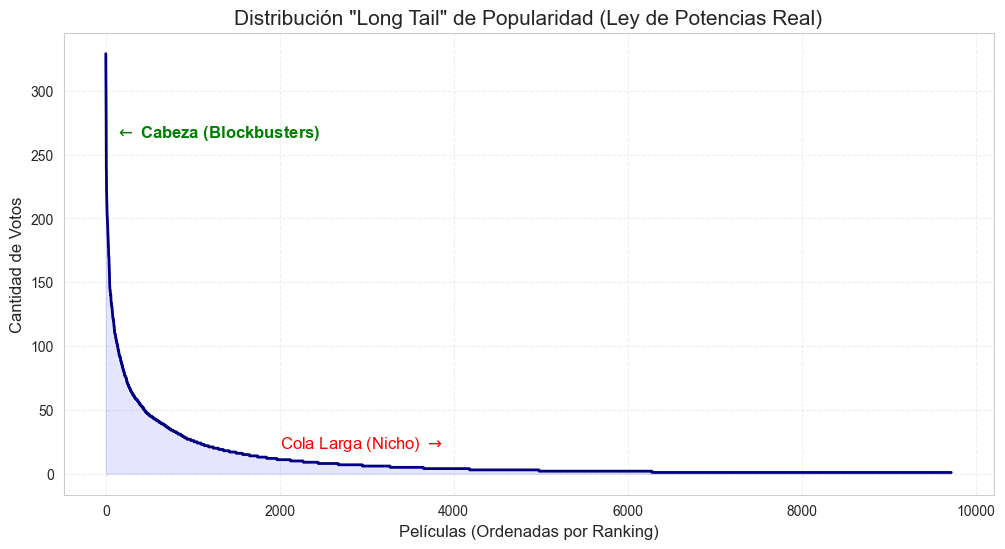

Insight: Observa la caída exponencial. Unas pocas películas tienen miles de vistas, mientras que la mayoría (la cola) tiene menos de 10.


In [6]:
# Calcular popularidad (Frecuencia de ratings por película)
movie_popularity = df['title'].value_counts().values

plt.figure(figsize=(12, 6))
# Graficamos la curva
plt.plot(movie_popularity, color='navy', linewidth=2)
# Rellenamos el área para efecto visual
plt.fill_between(range(len(movie_popularity)), movie_popularity, color='blue', alpha=0.1)

# Anotaciones para explicar el fenómeno a stakeholders
plt.title('Distribución "Long Tail" de Popularidad (Ley de Potencias Real)', fontsize=15)
plt.xlabel('Películas (Ordenadas por Ranking)', fontsize=12)
plt.ylabel('Cantidad de Votos', fontsize=12)
plt.text(100, movie_popularity[0]*0.8, r'$\leftarrow$ Cabeza (Blockbusters)', color='green', fontweight='bold', fontsize=12)
plt.text(2000, 20, r'Cola Larga (Nicho) $\rightarrow$', color='red', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print("Insight: Observa la caída exponencial. Unas pocas películas tienen miles de vistas, mientras que la mayoría (la cola) tiene menos de 10.")


### 3.2 Hipótesis 2: Estacionalidad Semanal
Analizamos si existe un patrón cíclico en el comportamiento del usuario dependiente del día de la semana $d$. Definimos la actividad diaria como:

$$ \text{Activity}_d = \sum_{i=1}^{N} \mathbb{1}(\text{day\_name}(t_i) = d) $$

Esperamos observar picos significativos durante los fines de semana, lo cual es relevante para escalar la infraestructura (servidores).

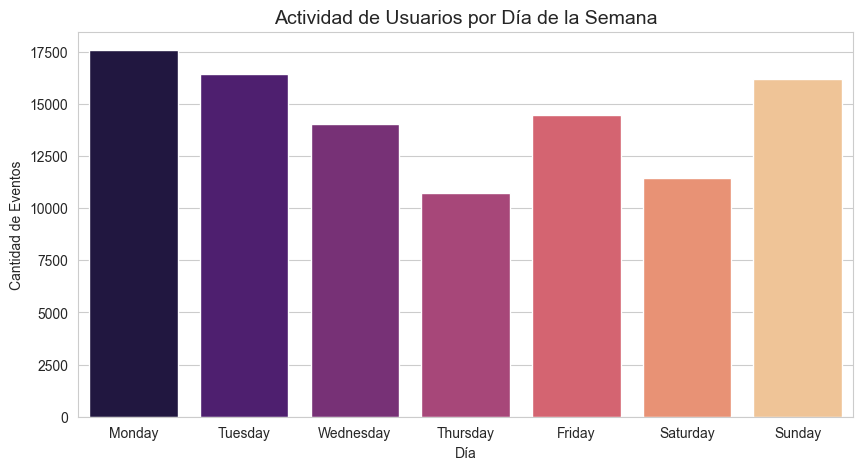

Insight: Analiza si el Sábado (Saturday) es el día pico. ¿Cae la actividad el Lunes?


In [7]:
# Extraer el nombre del día
df['day_of_week'] = df['timestamp_dt'].dt.day_name()

# Definir el orden lógico de la semana (si no, sale alfabético)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Contar y reordenar
weekly_activity = df['day_of_week'].value_counts().reindex(days_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=weekly_activity.index, y=weekly_activity.values, palette="magma", hue=weekly_activity.index, legend=False)

plt.title("Actividad de Usuarios por Día de la Semana", fontsize=14)
plt.ylabel("Cantidad de Eventos")
plt.xlabel("Día")
plt.show()

print("Insight: Analiza si el Sábado (Saturday) es el día pico. ¿Cae la actividad el Lunes?")